In [21]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

# 🧩 Problem: Quadratic Equation Analyzer

You need to build a small LangGraph conditional workflow that analyzes a quadratic equation:

```ax^2+bx+c=0```
Requirements

The application should accept three inputs:
- a
- b
- c

The workflow should first validate whether the equation is actually quadratic.

Then calculate the discriminant:

```D = b^2 − 4ac```

Based on the value of D, the workflow should determine:

- D > 0 → Two distinct real roots
- D = 0 → One repeated real root
- D < 0 → No real roots

In [22]:
class State(TypedDict):
    a: float
    b: float
    c: float

    disciminant: float
    answer: str

In [ ]:
# nodes

def calculate_discriminant(state: State):
    d = (state["b"]**2) - (4 * state["a"] * state["c"])
    return { "disciminant": d }

def two_real_roots(state: State):
    ans = "Having  two real roots"
    return { "answer": ans}

def one_root(state: State):
    ans = "Having exactly one real roots"
    return { "answer": ans}

def no_roots(state: State):
    ans = "No roots"
    return { "answer": ans}

    
    

In [ ]:
# condition ckecker nodes 
# it will return the name of the next executable node

def conditional_handler(state: State) -> Literal["one_root", "two_real_roots", "no_roots"]:
    if state["disciminant"] == 0:
        return "one_root"
    elif state["disciminant"] > 0:
        return "two_real_roots"
    else:
        return "no_roots"

def conditional_handler_without_literal(state: State):
    """
        without Literal[] in the return type the langgraph will work properly
        but at the time of printing the graph using image it will not show the edges
    """
    if state["disciminant"] == 0:
        return "one_root"
    elif state["disciminant"] > 0:
        return "two_real_roots"
    else:
        return "no_roots"
    

In [29]:
graph = StateGraph(State)

graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("two_real_roots", two_real_roots)
graph.add_node("no_roots", no_roots)
graph.add_node("one_root", one_root)


graph.add_edge(START, "calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant", conditional_handler)

graph.add_edge("one_root", END)
graph.add_edge("two_real_roots", END)
graph.add_edge("no_roots", END)



workflow = graph.compile()




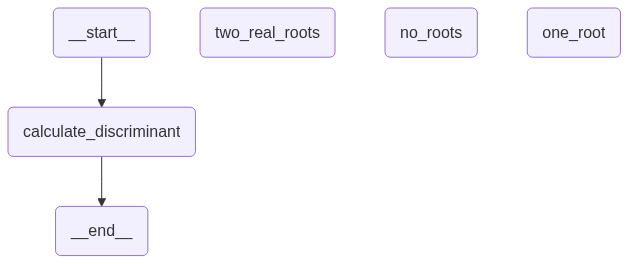

In [25]:
workflow

In [28]:
initial_state = {"a": 2, "b": 4, "c": 2}

output = workflow.invoke(initial_state)

print(output)

{'a': 2, 'b': 4, 'c': 2, 'disciminant': 0, 'answer': 'Having exactly one real roots'}
